In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("source/house-prices-tp.csv")
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.071510,0.000000,4.490000,0.0,0.449,6.121000,56.8,3.747600,3.000000,247.000000,18.500000,395.150000,8.440000,22.200000
1,0.082650,0.000000,13.920000,0.0,0.437,6.127000,18.4,5.502700,4.000000,289.000000,16.000000,396.900000,8.580000,23.900000
2,0.128160,12.500000,6.070000,0.0,0.409,5.885000,33.0,6.498000,4.000000,345.000000,18.900000,396.900000,8.790000,20.900000
3,0.088730,21.000000,5.640000,0.0,0.439,5.963000,45.7,6.814700,4.000000,243.000000,16.800000,395.560000,13.450000,19.700000
4,0.114320,0.000000,8.560000,0.0,0.520,6.781000,71.3,2.856100,5.000000,384.000000,20.900000,395.580000,7.670000,26.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,0.082440,30.000000,4.930000,0.0,0.428,6.481000,18.5,6.189900,6.000000,300.000000,16.600000,379.410000,6.360000,23.700000
552,0.475470,0.000000,9.900000,0.0,0.544,6.113000,58.8,4.001900,4.000000,304.000000,18.400000,396.230000,12.730000,21.000000
553,0.249800,0.000000,21.890000,0.0,0.624,5.857000,98.2,1.668600,4.000000,437.000000,21.200000,392.040000,21.320000,13.300000
554,32.504013,6.528591,8.937346,1.0,NaN,4.016588,NaN,5.243777,20.416908,197.236588,19.639059,6.267059,7.033962,23.028798


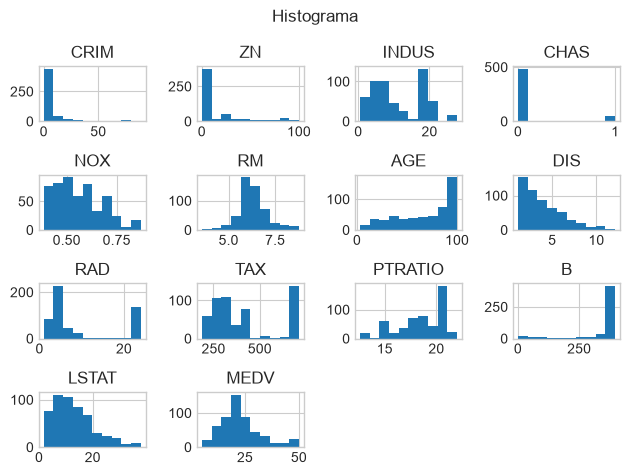

In [ ]:
#No hace falta correr, es para ver todos los histogramas de las variables.
df.hist()
plt.suptitle('Histograma')
plt.tight_layout()
plt.show()

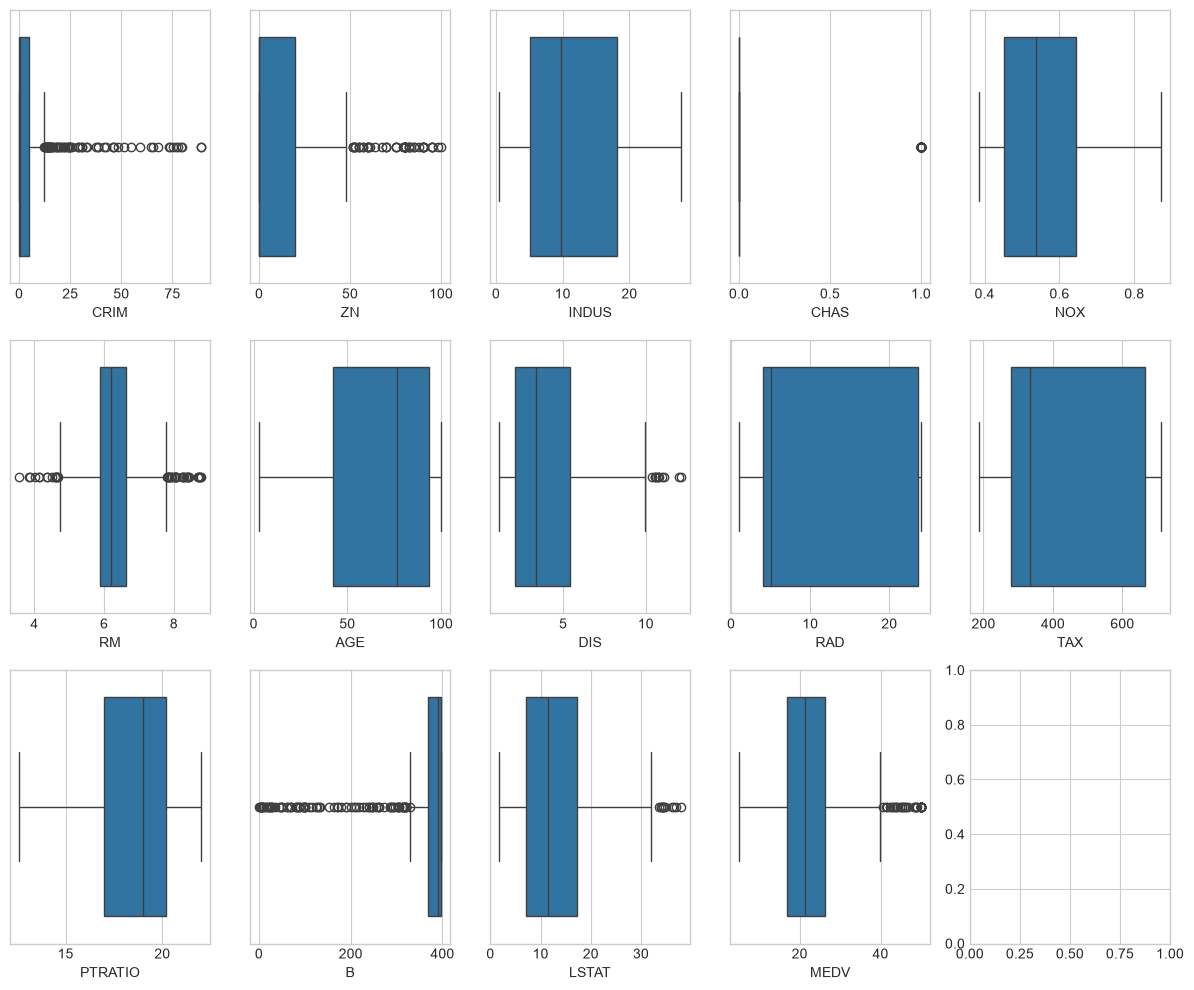

In [ ]:
cols = df.columns
fig, axes = plt.subplots(nrows=3, ncols=5, sharey=False, figsize=(12, 10))
for i, col in enumerate(cols, 1): sns.boxplot(data=df, x=col, ax=axes.flatten()[i-1])
plt.tight_layout()
plt.show()

Despues de un analisis en conjunto entre los datos y las descripciones de las variables llegamos a la conclusion de que CHAS es la unica variable a cambiar de tipo.
Notamos que existen muchos outliers, pero nos recomendaron mantenerlos, porque aportan mucha informacion.
Tambien existen algunos datos faltantes en el dataset

In [ ]:
df.isna().mean() * 100

CRIM       4.136691
ZN         3.956835
INDUS      2.697842
CHAS       4.136691
NOX        4.316547
RM         3.776978
AGE        4.316547
DIS        2.697842
RAD        5.035971
TAX        3.237410
PTRATIO    5.035971
B          3.956835
LSTAT      3.956835
MEDV       3.776978
dtype: float64

Revisamos el porcentaje de NaN por variables para tomar la decision de si eliminar filas de datos.

In [ ]:
filas_iniciales = len(df)

porcentaje_nan_por_fila = df.isna().mean(axis=1)
df = df.loc[porcentaje_nan_por_fila <= 0.30].copy()

filas_eliminadas = filas_iniciales - len(df)
print(f"Filas eliminadas: {filas_eliminadas}")
print(f"Filas restantes: {len(df)}")
print(f"Porcentaje de filas eliminadas: {filas_eliminadas / filas_iniciales * 100:.2f}%")

Filas eliminadas: 28
Filas restantes: 528
Porcentaje de filas eliminadas: 5.04%


Removimos todas aquellas filas que tengan mas o un 30% de sus datos como NaN, nos parecio corrector este porcentaje ya que representan un 5% de los datos, esta en el limite de lo permitido.

In [ ]:
porcentaje_nan = df.isna().mean() * 100
porcentaje_nan.sort_values()

INDUS      0.000000
DIS        0.378788
LSTAT      0.378788
NOX        0.568182
RM         0.568182
MEDV       0.568182
B          0.568182
CHAS       0.568182
TAX        0.757576
CRIM       0.946970
PTRATIO    1.136364
ZN         1.136364
AGE        1.515152
RAD        1.515152
dtype: float64

El procentaje de NaN en las variables despues de la limpieza es muy pequeña, por lo que podemos imputar datos sin que se consideren datos sinteticos.

In [ ]:
df = df.fillna(df.median())

Reemplazamos todos aquellos valores faltantes por la mediana de cada variable.

In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 528 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     528 non-null    float64
 1   ZN       528 non-null    float64
 2   INDUS    528 non-null    float64
 3   CHAS     528 non-null    float64
 4   NOX      528 non-null    float64
 5   RM       528 non-null    float64
 6   AGE      528 non-null    float64
 7   DIS      528 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      528 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        528 non-null    float64
 12  LSTAT    528 non-null    float64
 13  MEDV     528 non-null    float64
dtypes: float64(14)
memory usage: 61.9 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,5.007176,12.261131,11.236754,0.087121,0.559012,6.283307,68.003000,3.880434,9.557407,409.411470,18.445231,351.185586,12.891600,22.670369
std,12.146422,24.111924,6.909106,0.282280,0.118495,0.756884,28.171048,2.184309,8.632460,167.350774,2.171376,96.938585,7.439694,9.327546
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083827,0.000000,5.175000,0.000000,0.453000,5.877750,43.250000,2.110500,4.000000,280.511366,17.375000,371.990000,7.135000,16.950000
50%,0.289600,0.000000,9.690000,0.000000,0.538000,6.208000,76.600000,3.304487,5.000000,334.500000,19.000000,390.950000,11.395000,21.200000
75%,4.452190,20.000000,18.100000,0.000000,0.631720,6.630250,93.800000,5.255350,22.746235,666.000000,20.200000,396.007500,17.127500,25.125000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
#Utilizamos el metodo skew para ver la asimetria de las variables.
df.skew(numeric_only=True)

CRIM       4.196731
ZN         2.085877
INDUS      0.293200
CHAS       2.936436
NOX        0.700882
RM         0.326380
AGE       -0.575311
DIS        1.055636
RAD        0.999665
TAX        0.649373
PTRATIO   -0.811087
B         -2.582387
LSTAT      0.947417
MEDV       1.087243
dtype: float64

**Analisis de las variables mediante el uso del dataset limpio (estructura del analisis tomada de los ejemplos de Mineria de Datos).**

**CRIM** (tasa de criminalidad per cápita)<br>
>Media: 5.01 | Mediana: 0.29.<br>
>Rango: 0.006 - 88.98. Desviación estándar: 12.15 (mayor que la propia media).<br>
>Asimetría muy fuerte (skew = 4.20): la mayoría de las ciudades tiene criminalidad casi nula, pero un puñado de zonas muy peligrosas dispara el promedio muy por encima de la mediana.

**ZN** (proporción de terrenos residenciales en lotes grandes)<br>
>Media: 12.26 | Mediana: 0.00.<br>
>Rango: 0 - 100. Desviación estándar: 24.11.<br>
>Asimetría alta (skew = 2.09): más de la mitad de las ciudades tiene ZN = 0 (nada de lotes grandes), por eso la mediana es directamente 0, mientras que algunas zonas totalmente residenciales de baja densidad llevan la media hacia arriba.

**INDUS** (proporción de acres de negocio no minorista)<br>
>Media: 11.24 | Mediana: 9.69.<br>
>Rango: 0.46 - 27.74. Desviación estándar: 6.91.<br>
>Media y mediana cercanas y skew bajo (0.29): distribución razonablemente simétrica, sin outliers extremos.

**CHAS** (limitantes con el río Charles)<br>
>Es binaria (0/1), alrededor del 8.7% limitan con el río.

**NOX** (concentración de óxidos de nitrógeno)<br>
>Media: 0.559 | Mediana: 0.538.<br>
>Rango: 0.385 - 0.871. Desviación estándar: 0.119.<br>
>Asimetría moderada (skew = 0.70): hay más zonas con niveles de contaminación bajos-medios, con una cola de barrios más industriales/contaminados que empuja la media hacia arriba.

**RM** (habitaciones promedio por vivienda)<br>
>Media: 6.28 | Mediana: 6.21.<br>
>Rango: 3.56 - 8.78. Desviación estándar baja: 0.78.<br>
>Media y mediana casi iguales, es decir, distribución bastante simétrica, sin grandes outliers. Es la variable que más se parece a una normal de todo el dataset.

**AGE** (% de viviendas ocupadas por dueños, construidas antes de 1940)<br>
>Media: 68.00 | Mediana: 76.60.<br>
>Rango: 2.9 - 100. Desviación estándar: 28.17.<br>
>Asimetría negativa (skew = -0.58): acá la mediana supera a la media. La mayoría de los barrios tiene un parque habitacional bastante antiguo (valores altos), pero un grupo de zonas con construcciones mucho más nuevas arrastra la media hacia abajo.

**DIS** (distancia ponderada a centros de empleo)<br>
>Media: 3.88 | Mediana: 3.30.<br>
>Rango: 1.13 - 12.13. Desviación estándar: 2.18.<br>
>Asimetría alta (skew = 1.06): la mayoría de las propiedades está relativamente cerca de los centros de empleo, con algunas zonas muy alejadas que generan la cola larga a la derecha.

**RAD** (índice de accesibilidad a autopistas radiales)<br>
>Media: 9.56 | Mediana: 5.00.<br>
>Rango: 1 - 24. Desviación estándar: 8.63.<br>
>Asimetría marcada (skew = 1.00) y una desviación estándar casi tan grande como la media: esta variable tiene un comportamiento casi bimodal (muchos valores bajos, un salto grande hasta 24), típico de un índice categórico más que continuo.

**TAX** (tasa de impuesto a la propiedad)<br>
>Media: 409.41 | Mediana: 334.50.<br>
>Rango: 187 - 711. Desviación estándar: 167.35.<br>
>Asimetría moderada (skew = 0.65), coherente con RAD (ambas suelen moverse juntas): hay un grupo de zonas con impuestos mucho más altos que el resto.

**PTRATIO** (ratio alumno-maestro)<br>
>Media: 18.45 | Mediana: 19.00.<br>
>Rango: 12.6 - 22. Desviación estándar: 2.17.<br>
>Asimetría negativa leve (skew = -0.81): la mayoría de los distritos tiene ratios altos (cercanos al máximo), con algunos distritos con mucha mejor relación alumno-maestro que bajan el promedio.

**B** (resultado de B = 1000(Bk − 0.63)²)<br>
>Media: 347.81 | Mediana: 390.82.<br>
>Rango: 0.32 - 396.9. Desviación estándar alta: 99.64.<br>
>Asimetría negativa marcada (-2.58): acá la mediana supera a la media.

**LSTAT** (% de población de menor estatus socioeconómico)<br>
>Media: 13.03 | Mediana: 11.47.<br>
>Rango: 1.73 - 37.97. Desviación estándar: 7.58.<br>
>Asimetría moderada hacia la derecha: hay más barrios con porcentajes bajos, pero una cola de zonas con LSTAT muy alto que empuja la media hacia arriba.

**MEDV** (valor mediano de la vivienda, variable target)<br>
>Media: 22.75 k$ | Mediana: 21.20 k$.<br>
>Rango: 5.00 - 50.00 k$. Desviación estándar: 9.49.<br>
>Leve asimetría positiva. El máximo en 50.0 no es casual: es un valor "tope" (censurado) del dataset original de Boston, así que ese pico en 50 concentra más casos de los que esperaríamos en una cola normal.

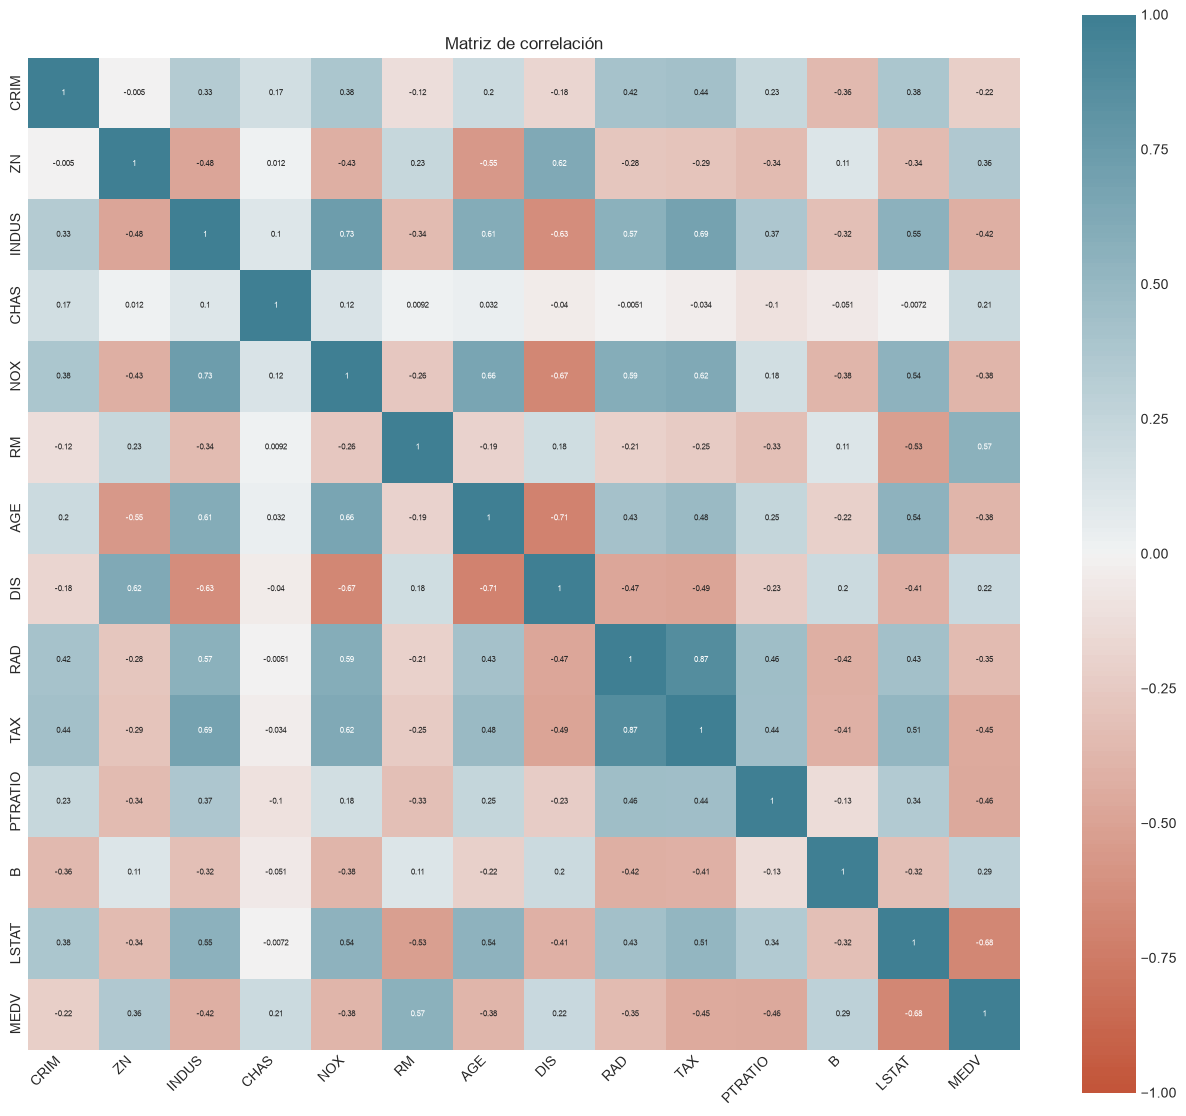

In [ ]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(16, 14))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

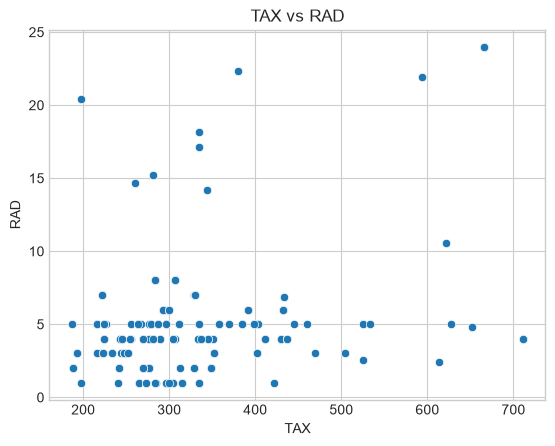

In [ ]:
sns.scatterplot(data=df, x='TAX', y='RAD')
plt.title('TAX vs RAD')
plt.show()

Multicolinealidad muy fuerte (0.87) esto nos indica que estas 2 variables independientes explican casi lo mismo. Esto es importante porque utilizar ambas nos va a dificultar la interpretacion de coeficientes y reducir la precision de nuestras estimaciones.
NOX vs INDUS, AGE vs DIS, NOX vs DIS y INDUS vs DIS tambien poseen un indice de correlacion alto pero consideramos que estan dentro de lo permitido.

In [ ]:
x = df.drop(columns=['MEDV'])
y = df['MEDV']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
pipeline = Pipeline([
    ('estandarizacion', StandardScaler()),
    ('modelo', LinearRegression())
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)
print(f"R-cuadrado (R2): {r2_score(y_test, y_pred)}")

R-cuadrado (R2): 0.6471191167073733


### Gradiente descendente

Probamos los tres métodos de gradiente descendente con las funciones provistas por la cátedra (`source/descenso_gradiente.py`, sin modificaciones), con sus hiperparámetros por defecto: lr = 0.01, 100 épocas y batch_size = 11 para mini-batch.

- **Batch (GD)**: calcula el gradiente con todas las casas de entrenamiento y actualiza los pesos una vez por época.
- **Estocástico (SGD)**: actualiza los pesos después de cada casa.
- **Mini-batch**: actualiza los pesos después de cada grupo de 11 casas.

In [ ]:
# Funciones de descenso del gradiente provistas por la cátedra
from source.descenso_gradiente import gradient_descent, stochastic_gradient_descent, mini_batch_gradient_descent

# Estandarizamos: el scaler se ajusta solo con train y se aplica a train y test
scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

# Las funciones necesitan el target como vector columna (n, 1)
y_train_2d = np.array(y_train).reshape(-1, 1)
y_test_2d = np.array(y_test).reshape(-1, 1)

**Figura 5 – Error vs épocas, gradiente descendente batch.** Eje x: épocas (una actualización de los pesos por época). Curvas: MSE de todo el conjunto de entrenamiento y de todo el conjunto de prueba (la función lo rotula "validación").

In [ ]:
# Figura 5: GD batch con los hiperparámetros por defecto de la cátedra
np.random.seed(42)
W_gd = gradient_descent(x_train_std, y_train_2d, x_test_std, y_test_2d)

En la Figura 5 el error baja de forma suave y pareja, porque cada paso usa el gradiente calculado con todas las casas. Sin embargo, a las 100 épocas la curva todavía sigue bajando: con lr = 0.01 cada paso es corto y no alcanza a llegar al mínimo.

**Figura 6 – Error vs iteraciones, gradiente descendente estocástico.** Eje x: iteraciones, una por casa (422 por época, 42.200 en total). Curva de entrenamiento: error al cuadrado de la única casa usada en cada paso. Curva de prueba: MSE de todo el conjunto de prueba.

In [ ]:
# Figura 6: SGD con los hiperparámetros por defecto de la cátedra
np.random.seed(42)
W_sgd = stochastic_gradient_descent(x_train_std, y_train_2d, x_test_std, y_test_2d)

En la Figura 6 la curva de entrenamiento salta mucho porque mide el error de una sola casa, y algunas son mucho más difíciles de predecir que otras. La que refleja el comportamiento del modelo es la de prueba: baja en las primeras iteraciones y después oscila sin estabilizarse. Con un paso fijo de 0.01, cada casa empuja los pesos para su lado y el modelo "rebota" alrededor del mínimo.

**Figura 7 – Error vs iteraciones, gradiente descendente mini-batch.** Eje x: iteraciones, una por lote de 11 casas (39 por época, 3.900 en total). Curva de entrenamiento: MSE de las casas del lote. Curva de prueba: MSE de todo el conjunto de prueba.

In [ ]:
# Figura 7: mini-batch con los hiperparámetros por defecto de la cátedra
np.random.seed(42)
W_mb = mini_batch_gradient_descent(x_train_std, y_train_2d, x_test_std, y_test_2d)

En la Figura 7 el error cae rápido en las primeras épocas y se estabiliza. La curva de entrenamiento tiene ruido porque se mide sobre un lote de 11 casas, pero mucho menos que en SGD: promediar varias casas da una dirección más confiable para actualizar los pesos.

In [ ]:
# R2 en prueba de cada método (W[0] es el término independiente y W[1:] los pesos de cada variable)
for nombre, W in {'GD (batch)': W_gd, 'SGD': W_sgd, 'Mini-batch': W_mb}.items():
    y_test_pred = W[0] + np.matmul(x_test_std, W[1:])
    print(f"R2 en prueba - {nombre}: {r2_score(y_test_2d, y_test_pred):.4f}")

**¿Algún cambio respecto de LinearRegression?** El modelo es el mismo; cambia la forma de encontrar los pesos. LinearRegression los calcula de forma exacta en un solo paso (R² de prueba 0.65), mientras que el gradiente descendente los busca iterando, y su resultado depende de la tasa de aprendizaje y de la cantidad de épocas. Con los valores por defecto, solo mini-batch llega al óptimo (R² 0.65, Figura 7). GD no llega a converger en 100 épocas (R² 0.54, Figura 5) y SGD oscila por un paso demasiado grande para actualizar casa por casa (R² 0.57, Figura 6).

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Entrenamos los tres modelos regularizados con hiperparámetros fijos
modelo_ridge = Ridge(alpha=1.0)
modelo_lasso = Lasso(alpha=0.1)
modelo_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)

modelo_ridge.fit(x_train_std, y_train)
modelo_lasso.fit(x_train_std, y_train)
modelo_enet.fit(x_train_std, y_train);

         Ridge  Lasso  ElasticNet
CRIM    -0.096 -0.000      -0.083
ZN       1.870  1.629       1.541
INDUS    0.516  0.000       0.019
CHAS     1.556  1.459       1.466
NOX     -0.885 -0.474      -0.520
RM       2.122  2.010       2.062
AGE     -0.278 -0.063      -0.257
DIS     -2.284 -1.919      -1.863
RAD      1.966  1.013       0.994
TAX     -2.528 -1.613      -1.521
PTRATIO -1.444 -1.270      -1.305
B        0.557  0.450       0.506
LSTAT   -3.849 -4.007      -3.700


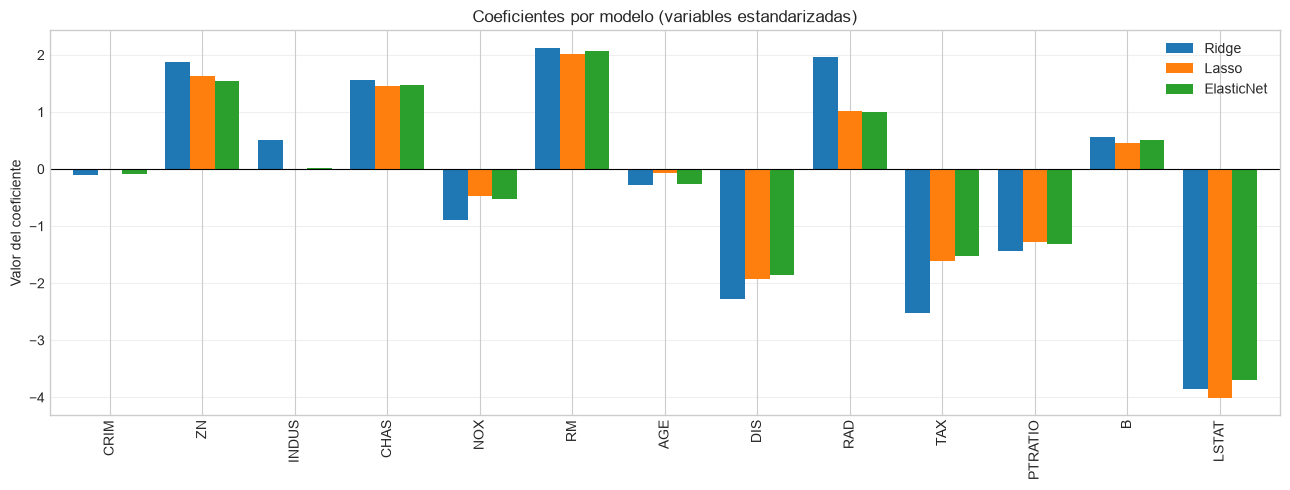

In [ ]:
# Comparamos los coeficientes de todos los modelos para ver el efecto de cada penalización
modelo_lr = pipeline.named_steps['modelo']

coefs = pd.DataFrame({
    'Ridge': modelo_ridge.coef_,
    'Lasso': modelo_lasso.coef_,
    'ElasticNet': modelo_enet.coef_
}, index=x.columns)

print(coefs.round(3))

# Gráfico de barras de los coeficientes para visualizar cuánto achica cada método
coefs.plot(kind='bar', figsize=(13, 5), width=0.8)
plt.title('Coeficientes por modelo (variables estandarizadas)')
plt.ylabel('Valor del coeficiente')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Las variables más influyentes en todos los modelos son **LSTAT**, **RM**, **DIS**, **TAX** y **PTRATIO**. Esto es coherente con el análisis descriptivo.
- **Ridge** da coeficientes casi idénticos a la regresión lineal. Con `alpha=1`, la penalización es muy chica en relación al error, así que casi no cambia nada.
- **Lasso** lleva a cero **CRIM** e **INDUS** y casi anula **AGE**: son las variables que menos aportan una vez que están las demás. También reduce **RAD** a la mitad y **TAX**, ambos estaban inflados por la multicolinealidad entre ellas.
- **Elastic Net** se comporta como un punto intermedio: achica como Lasso, pero no elimina del todo las variables porque la parte L2 las mantiene cerca de cero pero distintas de cero.

In [ ]:
# Función que calcula R2 para un modelo, tanto en train como en test
def calcular_r2(nombre, modelo, X_tr, X_te):
    return {
        'Modelo': nombre,
        'R2 Train': r2_score(y_train, modelo.predict(X_tr)),
        'R2 Test': r2_score(y_test, modelo.predict(X_te))
    }

resultados = [
    calcular_r2('Ridge', modelo_ridge, x_train_std, x_test_std),
    calcular_r2('Lasso', modelo_lasso, x_train_std, x_test_std),
    calcular_r2('ElasticNet', modelo_enet, x_train_std, x_test_std)
]

tabla_r2 = pd.DataFrame(resultados).set_index('Modelo')
tabla_r2.round(3)

,R2 Train,R2 Test
Modelo,,
Ridge,0.646,0.647
Lasso,0.641,0.638
ElasticNet,0.640,0.641


Comparar ambos conjuntoses lo que nos permite diagnosticar el ajuste:

- Las métricas en **train** miden qué tan bien el modelo aprendió los datos que vio. Si son malas, el modelo no tiene capacidad suficiente (**subajuste / alto sesgo**).
- Las métricas en **test** miden la capacidad de **generalizar** a datos nuevos, que es lo que realmente nos importa.
- Si train es muy bueno y test mucho peor, hay **sobreajuste** (alta varianza): el modelo memorizó ruido. Si ambos son parecidos y malos, hay subajuste. Mirar solo train no detecta el sobreajuste, y mirar solo test no nos dice cuál de los dos problemas tenemos.

En todos los modelos, R² es de aproximadamente 0.65 tanto en train como en test, es decir que la brecha entre ambos es mínima. Ridge y SGD dan prácticamente lo mismo que la regresión lineal, y Lasso / Elastic Net con estos alpha empeoran apenas el R² en train y en test, lo cual es esperable: la regularización reduce el sobreajuste, pero acá casi no había sobreajuste que reducir.

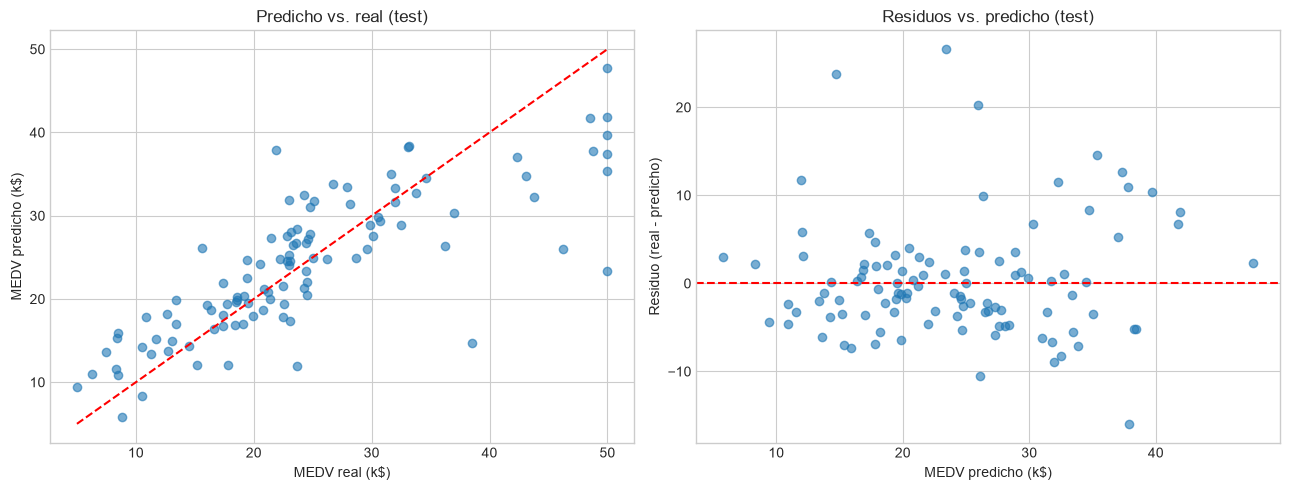

In [ ]:
# Usamos Ridge como representante (los cinco modelos dan resultados muy parecidos)
y_pred_test = modelo_ridge.predict(x_test_std)
residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicho vs real
axes[0].scatter(y_test, y_pred_test, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
axes[0].set_xlabel('MEDV real (k$)')
axes[0].set_ylabel('MEDV predicho (k$)')
axes[0].set_title('Predicho vs. real (test)')

# Residuos vs predicho
axes[1].scatter(y_pred_test, residuos, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('MEDV predicho (k$)')
axes[1].set_ylabel('Residuo (real - predicho)')
axes[1].set_title('Residuos vs. predicho (test)')

plt.tight_layout()
plt.show()

**Conclusión sobre el fitting: no, no es un buen ajuste.**

1. **R² ≈ 0.65** significa que el modelo deja sin explicar cerca de un tercio de la variabilidad del precio, lo cual es un ajuste mediano y no bueno.
2. **Train y test dan lo mismo**, así que el problema no es sobreajuste sino **subajuste**: el modelo lineal no tiene la flexibilidad suficiente para capturar la relación entre las variables y MEDV. Por eso la regularización no mejora nada, ya que su función es controlar la varianza, no el sesgo.
3. **Los gráficos lo confirman:** en el gráfico de predicho vs. real, las casas caras (real mayor a 40 k$) quedan casi todas por debajo de la diagonal (el modelo las subestima) y varias casas baratas (menos de 15 k$) quedan por encima (las sobreestima). En el de residuos hay además algunos errores muy grandes y los residuos tienden a ser positivos en los extremos y negativos en el centro, en vez de formar una nube aleatoria.

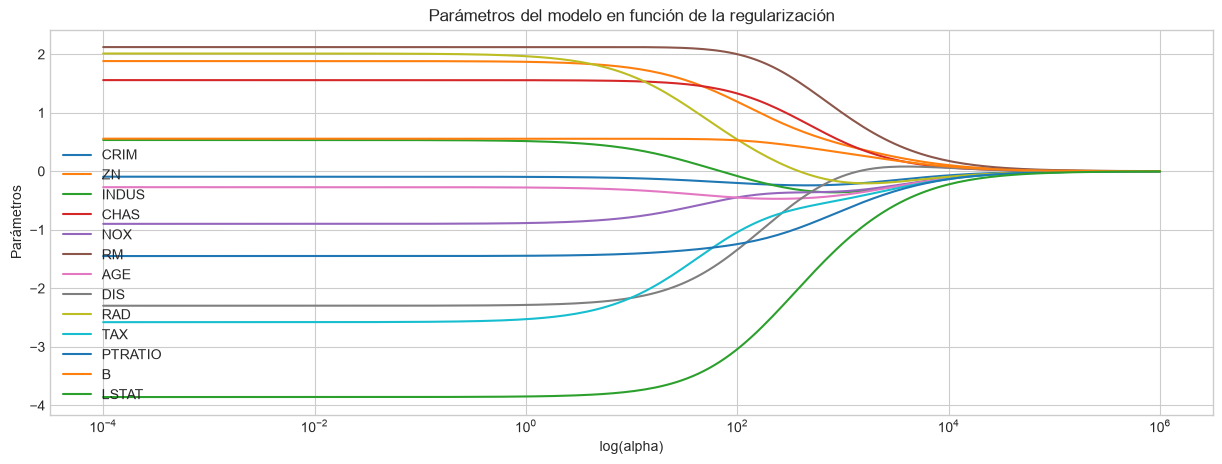

Mejor valor de alpha encontrado: 0.036543830709572546
R2 score en datos de prueba: 0.6455


In [ ]:
from sklearn.pipeline import make_pipeline

modelo = make_pipeline(StandardScaler(),
                        RidgeCV(
                           alphas          = np.logspace(-4, 6, 200),
                           fit_intercept   = True,
                           cv=None,
                           store_cv_results=True
                        )
         )

_ = modelo.fit(x_train, y_train)

alphas = modelo.steps[1][1].alphas
coefs = []

for alpha in alphas:
    modelo_aux = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    modelo_aux.fit(x_train, y_train)
    coefs.append(modelo_aux.steps[1][1].coef_.flatten())

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, coefs, label=x_train.columns)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('Parámetros')
ax.set_title('Parámetros del modelo en función de la regularización');
plt.axis('tight')
plt.legend()
plt.show()

print(f"Mejor valor de alpha encontrado: {mod.alpha_}")

y_pred = modelo.predict(x_test)

print(f"R2 score en datos de prueba: {r2_score(y_test, y_pred):.4f}")

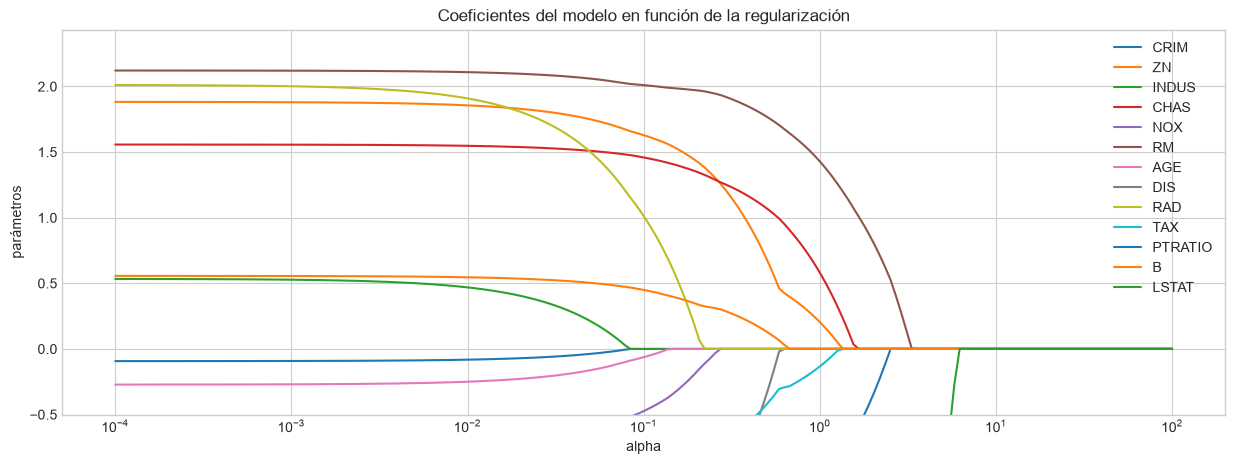

Mejor valor de alpha encontrado: 0.036543830709572546
R2 score en datos de prueba: 0.6445


In [ ]:
modelo = make_pipeline(StandardScaler(),
                        LassoCV(
                           alphas=np.logspace(-4, 2, 200),
                           cv=5
                        )
         )

_ = modelo.fit(x_train, y_train)

mod = modelo.steps[1][1]

alphas = mod.alphas_
coefs = []

for alpha in alphas:
    modelo_aux = make_pipeline(StandardScaler(), Lasso(alpha=alpha))
    modelo_aux.fit(x_train, y_train)
    coefs.append(modelo_aux.steps[1][1].coef_.flatten())

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(alphas, coefs, label=x_train.columns)
ax.set_xscale('log')
ax.set_ylim([-0.5,None])
ax.set_xlabel('alpha')
ax.set_ylabel('parámetros')
ax.legend()
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.show()

print(f"Mejor valor de alpha encontrado: {mod.alpha_}")

y_pred = modelo.predict(x_test)

print(f"R2 score en datos de prueba: {r2_score(y_test, y_pred):.4f}")